In [1]:
import auditok
import numpy as np
import sounddevice as sd

In [2]:
print(sd.query_devices())
print(sd.default.device)

< 0 HDA NVidia: HDMI 0 (hw:0,3), ALSA (0 in, 8 out)
  1 HDA NVidia: HDMI 1 (hw:0,7), ALSA (0 in, 8 out)
  2 HDA NVidia: HDMI 2 (hw:0,8), ALSA (0 in, 8 out)
  3 HDA NVidia: HDMI 3 (hw:0,9), ALSA (0 in, 8 out)
> 4 HDA Intel PCH: ALC285 Analog (hw:1,0), ALSA (2 in, 2 out)
  5 HDA Intel PCH: HDMI 0 (hw:1,3), ALSA (0 in, 8 out)
  6 HDA Intel PCH: HDMI 1 (hw:1,7), ALSA (0 in, 8 out)
  7 HDA Intel PCH: HDMI 2 (hw:1,8), ALSA (0 in, 8 out)
  8 hdmi, ALSA (0 in, 8 out)
[4, 0]


In [3]:
import pyaudio

p = pyaudio.PyAudio()
for i in range(p.get_device_count()):
    dev = p.get_device_info_by_index(i)
    if dev["maxInputChannels"] > 0:
        print(
            f"Index {i}: {dev['name']} | "
            f"inputs={int(dev['maxInputChannels'])} | "
            f"default_rate={int(dev['defaultSampleRate'])}"
        )
p.terminate()

Index 4: HDA Intel PCH: ALC285 Analog (hw:1,0) | inputs=2 | default_rate=48000


In [11]:
# Capture five seconds from the physical microphone.
MIC_DEVICE = 4
SAMPLE_RATE = 48000

five_sec_audio = auditok.load(
    None,
    sr=SAMPLE_RATE,
    sw=2,
    ch=1,
    max_read=5,
    input_device_index=MIC_DEVICE,
)
print(f"Captured {five_sec_audio.duration:.2f} seconds at {SAMPLE_RATE} Hz")

Captured 5.00 seconds at 48000 Hz


|               |[03:46/5.000]


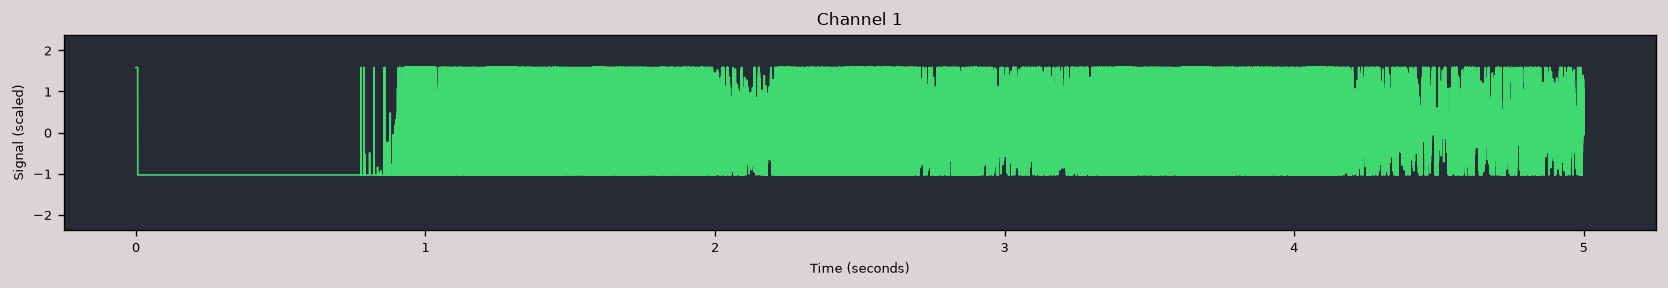

In [12]:
five_sec_audio.plot()

In [13]:
five_sec_audio.play(progress_bar=True)

PortAudioError: Error opening RawOutputStream: Device unavailable [PaErrorCode -9985]

In [ ]:
samples = np.frombuffer(five_sec_audio.data, dtype=np.int16)
values = samples.astype(np.float64)
print(
    f"samples={samples.size}, rms={np.sqrt(np.mean(values ** 2)):.1f}, "
    f"peak={np.max(np.abs(values))}"
)

In [ ]:
# Play the boosted recording through the analog output.
sd.play(
    boosted_samples,
    samplerate=SAMPLE_RATE,
    device=MIC_DEVICE,
    blocking=True,
)
print("Boosted playback complete")